In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [5]:
from ..utils.utils import Config

ImportError: attempted relative import with no known parent package

In [58]:
data = pd.read_csv("../data/data_for_lr.csv")
data = data.apply(pd.to_numeric, errors='coerce')

In [59]:
def train_test_split(X, y, test_size=0.25, shuffle=True, seed=None):
    if seed is not None:
        random.seed(seed)

    assert len(X) == len(y), "Error: length of X and y are not the same"

    n_samples = len(X)
    test_size = int(test_size * n_samples) 
    indices = list(range(n_samples))

    if shuffle:
        random.shuffle(indices)

    train_indices = indices[test_size:]
    test_indices = indices[:test_size]
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    return X_train, X_test, y_train, y_test

In [60]:
data.columns
X = np.array(data.drop("y", axis=1))
y = np.array(data['y'])

X_train, X_test, y_train, y_test = train_test_split(X,y)

In [67]:
class LinearRegression:
    def __init__(self, learning_rate=0.0001, epochs=25):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coefs = None
        self.loss = []

    def fit(self, X_train, y_train):
        ones = np.ones((X_train.shape[0], 1))
        X_train_b = np.hstack([ones, X_train])

        self.coefs =  np.random.uniform(0,1, size=(X_train_b.shape[1], 1)) * -0.01   # y = MX + c -- c considered as array of 1 (both weights and biases considered here)
        for _ in range(self.epochs):
            y_pred = self.forward_propagation(X_train_b)
            # print(y_pred)
            cost = self.cost_function(y_pred, y_train)
            self.loss.append(cost)
            gradient = self.backward_propagation(X_train_b, y_train, y_pred)
            self.coefs = self.coefs - (self.learning_rate * gradient)
            # print(self.coefs)
    

    def predict(self, X):
        ones = np.ones((X.shape[0], 1))
        X = np.hstack([ones, X])
        return X @ self.coefs
        

    def forward_propagation(self, X_train_b):
        # y = MX 
        y_pred = X_train_b @ self.coefs
        return y_pred


    def cost_function(self, y_pred, y_train):
        # mean squared error
        errors = y_pred - y_train.reshape(-1,1)
        cost = np.mean((errors) ** 2)
        return cost


    def backward_propagation(self, X_train_b, y_train, y_pred):
        errors = y_pred - y_train.reshape(-1,1)
        gradient = (1 / X_train_b.shape[0]) * X_train_b.T @ errors   # (1/num_rows)*X_transpose @ errors
        return gradient


    def plot_cost(self):
        plt.plot(range(self.epochs), self.loss)

In [68]:
lr = LinearRegression()
lr.fit(X_train,y_train)

In [69]:
y_pred = lr.predict(X_test)

In [70]:
y_pred

array([[  90.02843887],
       [  49.02193397],
       [  56.02304456],
       [  89.02828021],
       [  91.02859753],
       [  71.0254244 ],
       [  25.01812623],
       [  46.021458  ],
       [  45.02129935],
       [  58.02336188],
       [  87.0279629 ],
       [  73.02574172],
       [  86.02780425],
       [  29.01876085],
       [  75.02605903],
       [  43.02098203],
       [   9.01558773],
       [  88.02812156],
       [  39.02034741],
       [  91.02859753],
       [  51.02225128],
       [  30.01891951],
       [  43.02098203],
       [  12.0160637 ],
       [  56.02304456],
       [  98.02970812],
       [  86.02780425],
       [  48.02177531],
       [  49.02193397],
       [  77.02637634],
       [  17.01685698],
       [  30.01891951],
       [  51.02225128],
       [  85.02764559],
       [  93.02891484],
       [  52.02240994],
       [  15.01653966],
       [  86.02780425],
       [  35.01971279],
       [  21.0174916 ],
       [  89.02828021],
       [  35.019

In [71]:
lr.cost_function(y_pred, y_test)

np.float64(nan)

In [72]:
X_train.shape

(525, 1)

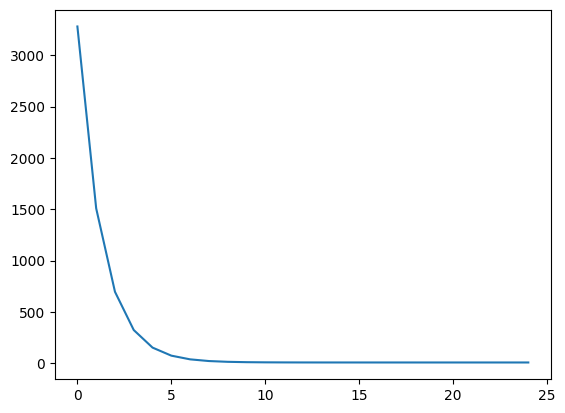

In [73]:
lr.plot_cost()